In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv("/content/DataCoSupplyChainDataset.csv")

Descriptive statistics


In [5]:
df.describe()

,Days_for_shipping_real,Days_for _shipment_scheduled,Benefit_per_order,Sales_per_customer,Late_delivery_risk,Category_Id,Customer_Id,Order_Id,Order_Item_Discount,Order_item_Discount_Rate,Order_Item_Id,Order_Item_Product_Price,Order_Item _Quantity,Sales,Order_Item_Total,Order_Profit_Per_Order,Product_Category_Id,Product_Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,36221.894903,20.664741,0.101668,90260.000000,141.232550,2.127638,203.772096,183.107609,21.974989,31.851451,141.232550
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,21045.379569,21.800901,0.070415,52111.490959,139.732492,1.453451,132.273077,120.043670,104.433526,15.640064,139.732492
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,9.990000,1.000000,9.990000,7.490000,-4274.979980,2.000000,9.990000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,18057.000000,5.400000,0.040000,45130.500000,50.000000,1.000000,119.980003,104.379997,7.000000,18.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,36140.000000,14.000000,0.100000,90260.000000,59.990002,1.000000,199.919998,163.990005,31.520000,29.000000,59.990002
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,54144.000000,29.990000,0.160000,135389.500000,199.990005,3.000000,299.950012,247.399994,64.800003,45.000000,199.990005
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,77204.000000,500.000000,0.250000,180519.000000,1999.989990,5.000000,1999.989990,1939.989990,911.799988,76.000000,1999.989990


. Mean days for real shipping is around 3 days with only 1 standard deviation and max days goes to 6 days sometime which we should reduce by identifying regions and delay reason
. Avg Sales per customer is around 180 while it has very high deviation of 100
while some sales goes up to 1900 shows high value customers
. while looking at avg discount it is 20 but the highest value is 500 which could be problematic for our profit
. profit per order shows high fluctuations with range of 100 - 900 which means some order are giving very high profit while some order are giving us medium profit

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 33 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Type                          180519 non-null  object 
 1   Days_for_shipping_real        180519 non-null  int64  
 2   Days_for _shipment_scheduled  180519 non-null  int64  
 3   Benefit_per_order             180519 non-null  float64
 4   Sales_per_customer            180519 non-null  float64
 5   Delivery_Status               180519 non-null  object 
 6   Late_delivery_risk            180519 non-null  int64  
 7   Category_Id                   180519 non-null  int64  
 8   Category_Name                 180519 non-null  object 
 9   Customer_City                 180519 non-null  object 
 10  Customer_Country              180519 non-null  object 
 11  Customer_Id                   180519 non-null  int64  
 12  Customer_Segment              180519 non-nul

In [7]:
df.head()

,Type,Days_for_shipping_real,Days_for _shipment_scheduled,Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Item_Total,Order_Profit_Per_Order,Order_Region,Order_State,Order_Status,Product_Category_Id,Product_Name,Product_Price,shipping_date_DateOrders,Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,73,Smart watch,327.75,02-03-2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,311.359985,-249.089996,South Asia,FALSE,PENDING,73,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,309.720001,-247.779999,South Asia,FALSE,CLOSED,73,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,304.809998,22.860001,Oceania,Queensland,COMPLETE,73,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,73,Smart watch,327.75,1/15/2018 11:24,Standard Class


In [8]:
df.select_dtypes(include=['number']).columns

Index(['Days_for_shipping_real', 'Days_for _shipment_scheduled',
       'Benefit_per_order', 'Sales_per_customer', 'Late_delivery_risk',
       'Category_Id', 'Customer_Id', 'Order_Id', 'Order_Item_Discount',
       'Order_item_Discount_Rate', 'Order_Item_Id', 'Order_Item_Product_Price',
       'Order_Item _Quantity', 'Sales', 'Order_Item_Total',
       'Order_Profit_Per_Order', 'Product_Category_Id', 'Product_Price'],
      dtype='object')

In [9]:
df.select_dtypes(include=['object']).columns

Index(['Type', 'Delivery_Status', 'Category_Name', 'Customer_City',
       'Customer_Country', 'Customer_Segment', 'Market', 'Order_Country',
       'order_date_DateOrders', 'Order_Region', 'Order_State', 'Order_Status',
       'Product_Name', 'shipping_date_DateOrders', 'Shipping_Mode'],
      dtype='object')

Data Cleaning step


In [10]:
# Removing Null values
df.isnull().sum()

,0
Type,0
Days_for_shipping_real,0
Days_for _shipment_scheduled,0
Benefit_per_order,0
Sales_per_customer,0
Delivery_Status,0
Late_delivery_risk,0
Category_Id,0
Category_Name,0
Customer_City,0


In [11]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

Exploratory Data Analysis


In [12]:
df['Type'].unique()

array(['DEBIT', 'TRANSFER', 'CASH', 'PAYMENT'], dtype=object)

In [13]:
df['Type'].value_counts()

,count
Type,
DEBIT,69295
TRANSFER,49883
PAYMENT,41725
CASH,19616


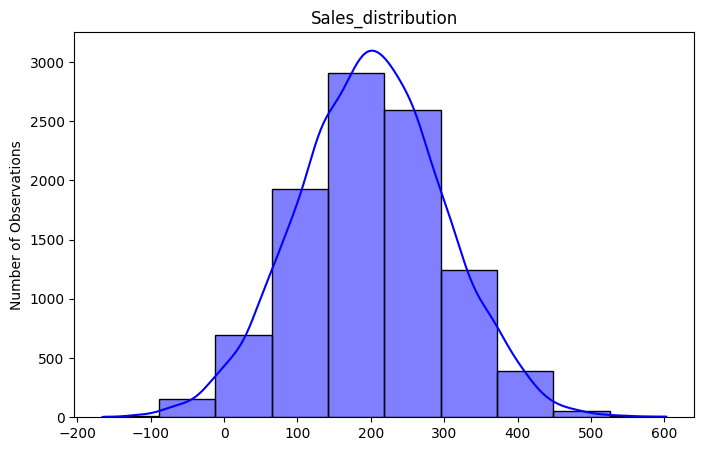

In [14]:
np.random.seed(1)

df2 = pd.DataFrame({'Sales':np.random.normal(loc =200, scale = 100, size = 10000)})
plt.figure(figsize = (8, 5))
sns.histplot(data = df2, x = 'Sales', bins = 10,kde=True,color='Blue')

plt.title('Sales_distribution')
plt.xlabel('')
plt.ylabel('Number of Observations')

plt.show()

Sales Data shows normal distribution pattern where falls around 200 and has some outliers in the range of negative values and 500-600.

<Figure size 800x300 with 0 Axes>

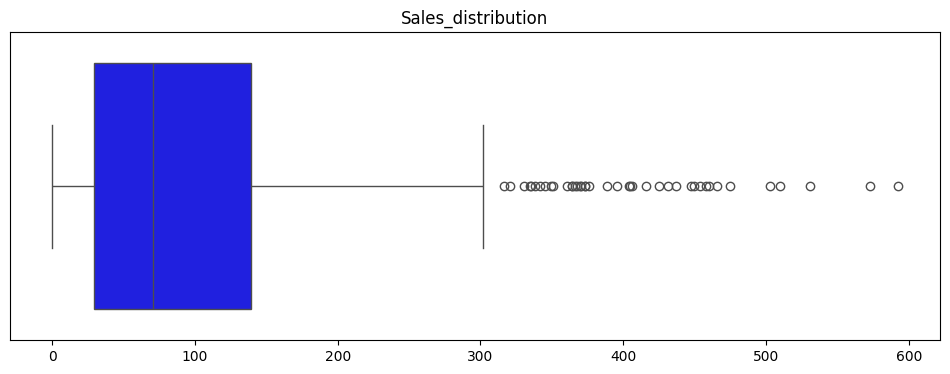

In [15]:
np.random.seed(1)

dfb = pd.DataFrame({'Sales': np.random.exponential(scale = 100, size = 1000)})

plt.figure(figsize = (8, 3))

plt.figure(figsize = (12, 4))


sns.boxplot(data = dfb, x = 'Sales', color='blue')

plt.title('Sales_distribution')
plt.xlabel('')
plt.ylabel('')
plt.yticks([])
plt.show()

Majority transactions concentrated in the range of 0 to 250. but some multiple outliers are present at 300+ which represents premium customer segment of our supply chain.


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 33 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Type                          180519 non-null  object 
 1   Days_for_shipping_real        180519 non-null  int64  
 2   Days_for _shipment_scheduled  180519 non-null  int64  
 3   Benefit_per_order             180519 non-null  float64
 4   Sales_per_customer            180519 non-null  float64
 5   Delivery_Status               180519 non-null  object 
 6   Late_delivery_risk            180519 non-null  int64  
 7   Category_Id                   180519 non-null  int64  
 8   Category_Name                 180519 non-null  object 
 9   Customer_City                 180519 non-null  object 
 10  Customer_Country              180519 non-null  object 
 11  Customer_Id                   180519 non-null  int64  
 12  Customer_Segment              180519 non-nul

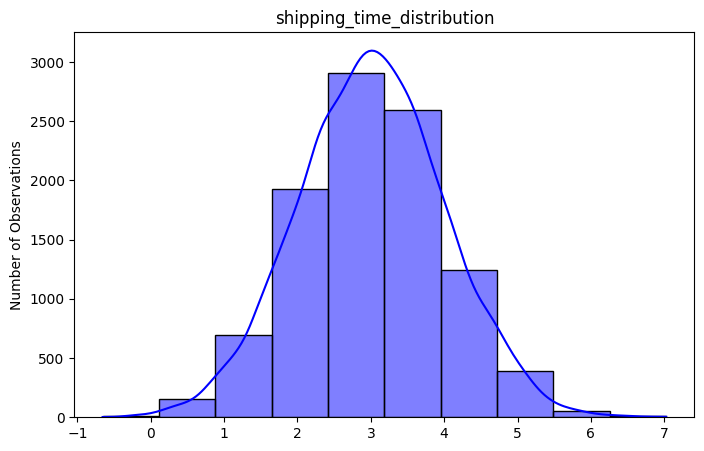

In [19]:
np.random.seed(1)

df2 = pd.DataFrame({'Days_for_shipping_real':np.random.normal(loc =3, scale = 1, size = 10000)})
plt.figure(figsize = (8, 5))
sns.histplot(data = df2, x = 'Days_for_shipping_real', bins = 10,kde=True,color='Blue')

plt.title('shipping_time_distribution')
plt.xlabel('')
plt.ylabel('Number of Observations')

plt.show()

Shipping time follows bell curve where average real time shipping duration is 3 days.Majority Orders are shipped in the operational window of 2 to 4 days


In [20]:
df_group = df.groupby("Type")['Sales'].sum().reset_index()

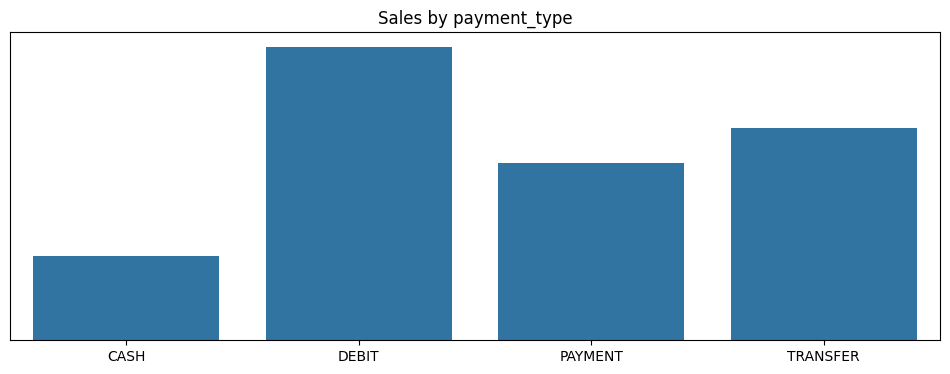

In [22]:
plt.figure(figsize = (12, 4))


sns.barplot(data = df_group, x = 'Type', y = 'Sales')

plt.title('Sales by payment_type')
plt.xlabel('')
plt.ylabel('')
plt.yticks([])
plt.show()



This bar shows that Debit Card drives the highest sale and Transfer is the second most useful payment method while cash transaction holds lowest revenue share

In [23]:
df['Delivery_Status'].value_counts()


,count
Delivery_Status,
Late delivery,98977
Advance shipping,41592
Shipping on time,32196
Shipping canceled,7754


In [24]:
df1_group = df.groupby("Delivery_Status")['Order_Id'].count().reset_index()

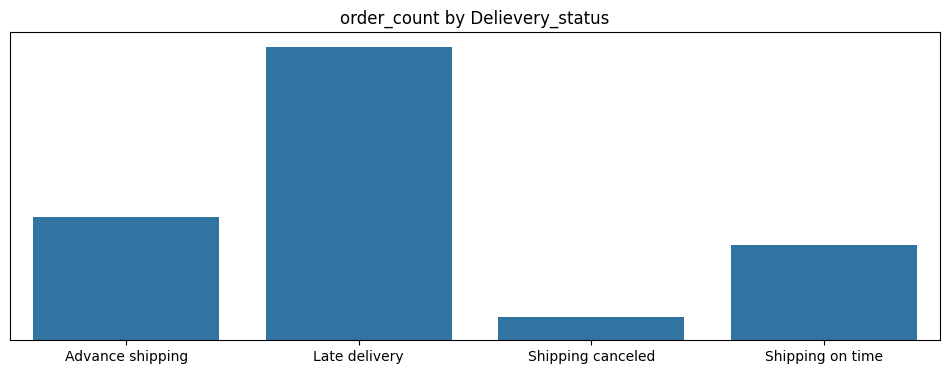

In [25]:
plt.figure(figsize = (12, 4))


sns.barplot(data = df1_group, x = 'Delivery_Status', y = 'Order_Id')

plt.title('order_count by Delievery_status')
plt.xlabel('')
plt.ylabel('')
plt.yticks([])
plt.show()

Majority Order are in late delivery category which indicate bottleneck in supply chain fullfilment while very few delivery are canceled. This indicates our product trustability and demands.

In [26]:
df['Order_Status'].value_counts()

,count
Order_Status,
COMPLETE,59491
PENDING_PAYMENT,39832
PROCESSING,21902
PENDING,20227
CLOSED,19616
ON_HOLD,9804
SUSPECTED_FRAUD,4062
CANCELED,3692
PAYMENT_REVIEW,1893


In [27]:
df3_group = df.groupby("Order_Status")['Order_Id'].count().reset_index()

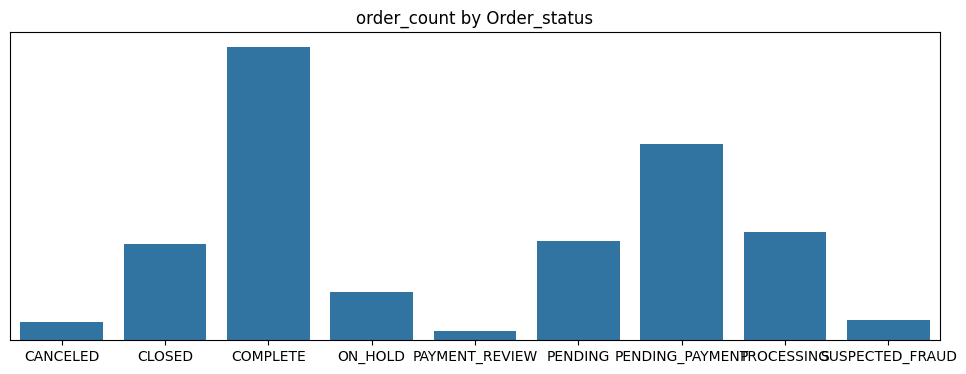

In [28]:
plt.figure(figsize = (12, 4))


sns.barplot(data = df3_group, x = 'Order_Status', y = 'Order_Id')

plt.title('order_count by Order_status')
plt.xlabel('')
plt.ylabel('')
plt.yticks([])
plt.show()

It shows that complete and pending payment are in top of order status. These high no of pending payment may be due to technical issue in payment section of online transaction. looking at suspected fraud it limits to low  order volume
but should be identified .

In [29]:
df['Order_Region'].value_counts()

,count
Order_Region,
Central America,28341
Western Europe,27109
South America,14935
Oceania,10148
Northern Europe,9792
Southeast Asia,9539
Southern Europe,9431
Caribbean,8318
West of USA,7993


In [30]:
dfa=df.groupby("Market")['Sales'].sum().reset_index()

In [31]:
print(dfa)

         Market         Sales
0        Africa  2.294453e+06
1        Europe  1.087240e+07
2         LATAM  1.027761e+07
3  Pacific Asia  8.273744e+06
4          USCA  5.066529e+06


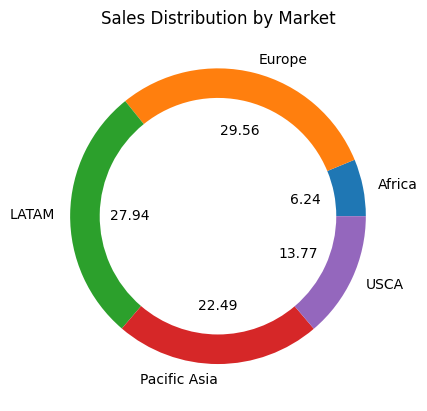

In [32]:


plt.pie(dfa['Sales'], labels = dfa['Market'], autopct = '%1.2f', wedgeprops = {'width' : 0.2})

plt.title('Sales Distribution by Market')

plt.show()

This donut chart shows Europe and LATAM are leading market in global sales with USCA & Africa are the lowest contributing regions

In [33]:
df4 = df['Customer_Segment'].value_counts()

In [34]:
df4=df.groupby("Customer_Segment")['Order_Item_Total'].sum().reset_index()

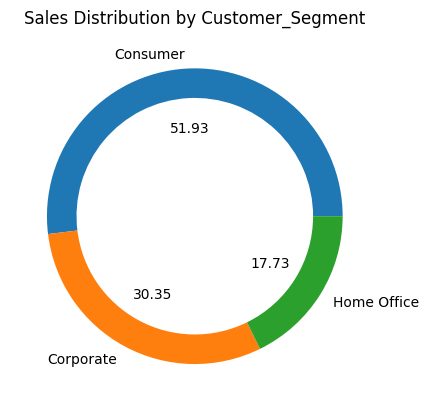

In [35]:
plt.pie(df4['Order_Item_Total'], labels = df4['Customer_Segment'], autopct = '%1.2f', wedgeprops = {'width' : 0.2})

plt.title('Sales Distribution by Customer_Segment')

plt.show()

Most of our business revenue around half of revenue comes from consumer segment while corporate is our second largest segment with smaller contribution from Home office segment.

In [36]:
df['Market'].value_counts()

,count
Market,
LATAM,51594
Europe,50252
Pacific Asia,41260
USCA,25799
Africa,11614


In [37]:
dfaa_group = df.groupby("Market")['Order_Item_Total'].sum().reset_index()

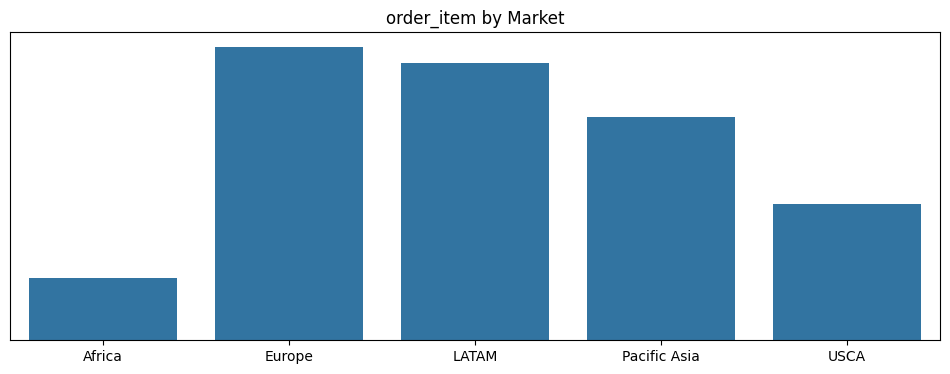

In [41]:
plt.figure(figsize = (12, 4))


sns.barplot(data = dfaa_group, x = 'Market', y = 'Order_Item_Total')

plt.title('order_item by Market')
plt.xlabel('')
plt.ylabel('')
plt.yticks([])
plt.show()

It shows that our growing markets are Europe and LATAM in terms of product demand so we should keep our stock updated and on time to increase our profit
while pacific asia is third largest growing market in this region our focus should be to increase our demands

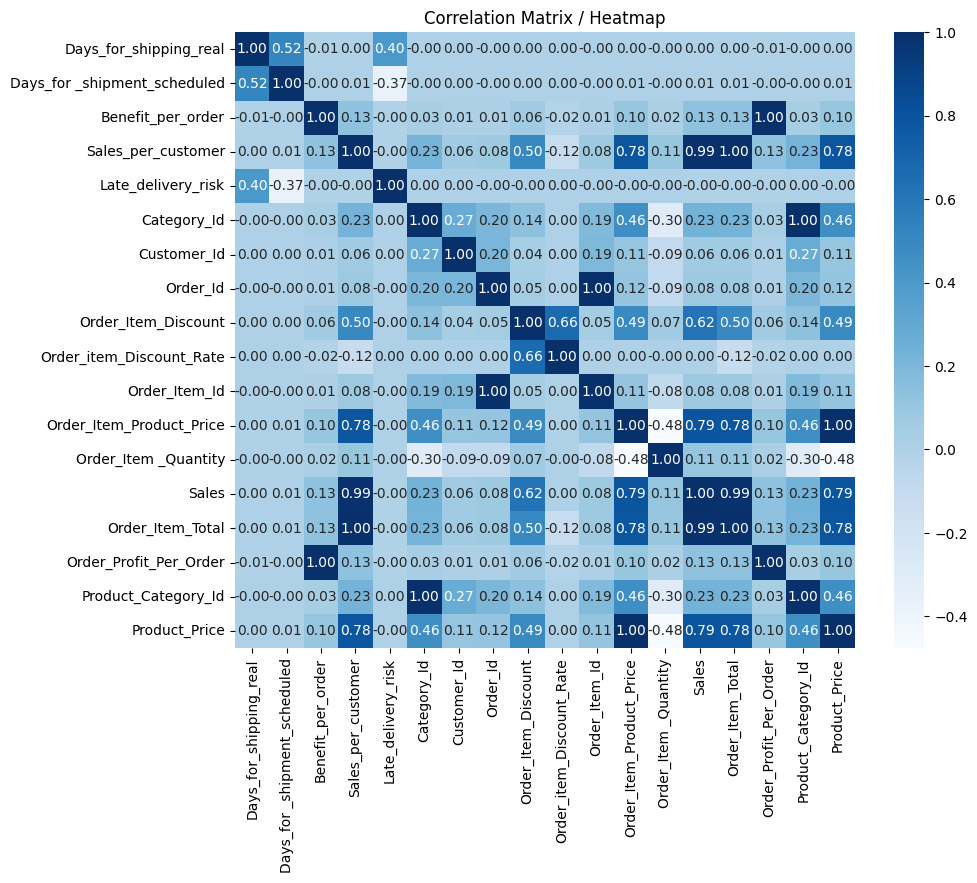

In [39]:
# Correlation heatmap
plt.figure(figsize = (10, 8))

sns.heatmap(df.select_dtypes(include=['number']).corr(), annot = True, fmt = '.2f', cmap = 'Blues')

plt.title('Correlation Matrix / Heatmap')

plt.show()

sales per customer ,sales,order item total shows nearly perfect positive correlation with each other indicates that  overallrevenue drives from order items. days for shipping real shows medium relationship with days for shipping scheduled means their is possiblity of  delivery delay .sales per customer and order item discount relationship shows that with increase in discount sales got affected


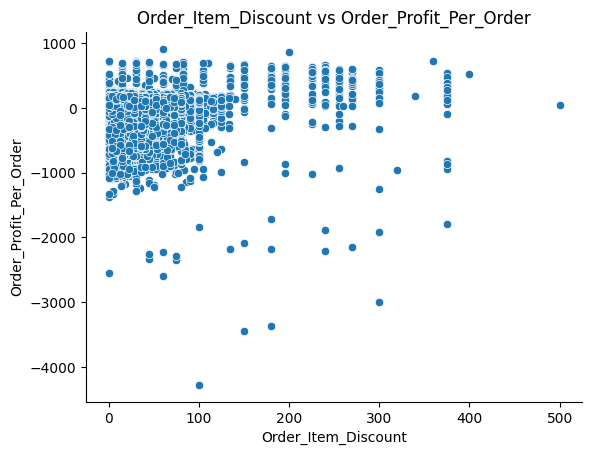

In [40]:
# Binary Correlation
sns.scatterplot(data = df, x = 'Order_Item_Discount', y = 'Order_Profit_Per_Order')

plt.title('Order_Item_Discount vs Order_Profit_Per_Order')

plt.gca().spines[['top', 'right']].set_visible(False)

plt.show()

As discount shows negative impact in profit in this data most of high discount transactions falls in the negative profit region which means giving discount reduce company profit so we should adapt new factor to increase sales